In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Initial configuration
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 30
LEARNING_RATE = 1e-4
SEED = 42

2026-02-08 00:15:22.883145: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770509723.099490      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770509723.164687      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770509723.689954      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770509723.689989      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770509723.689992      23 computation_placer.cc:177] computation placer alr

In [2]:
# Add data
DATA_DIR = '/kaggle/input/breast-cancer-detection' 

print("\n Preparing Data Loaders...")

# Training Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation/Test
test_val_datagen = ImageDataGenerator(rescale=1./255)

# Load Data from Directories
train_ds = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=SEED
)

valid_ds = test_val_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'valid'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_ds = test_val_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


 Preparing Data Loaders...
Found 2372 images belonging to 2 classes.
Found 675 images belonging to 2 classes.
Found 336 images belonging to 2 classes.


In [3]:
# Prepare model

print("\n Building Model (DenseNet121)...")

# Load Pretrained Base
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Freeze base model initially
base_model.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x) 
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Recall(name='recall')]
)

model.summary()


 Building Model (DenseNet121)...


I0000 00:00:1770509740.034584      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770509740.040675      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,304,257 (27.86 MB)

 Trainable params: 264,705 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)


 Visualizing Training Samples...


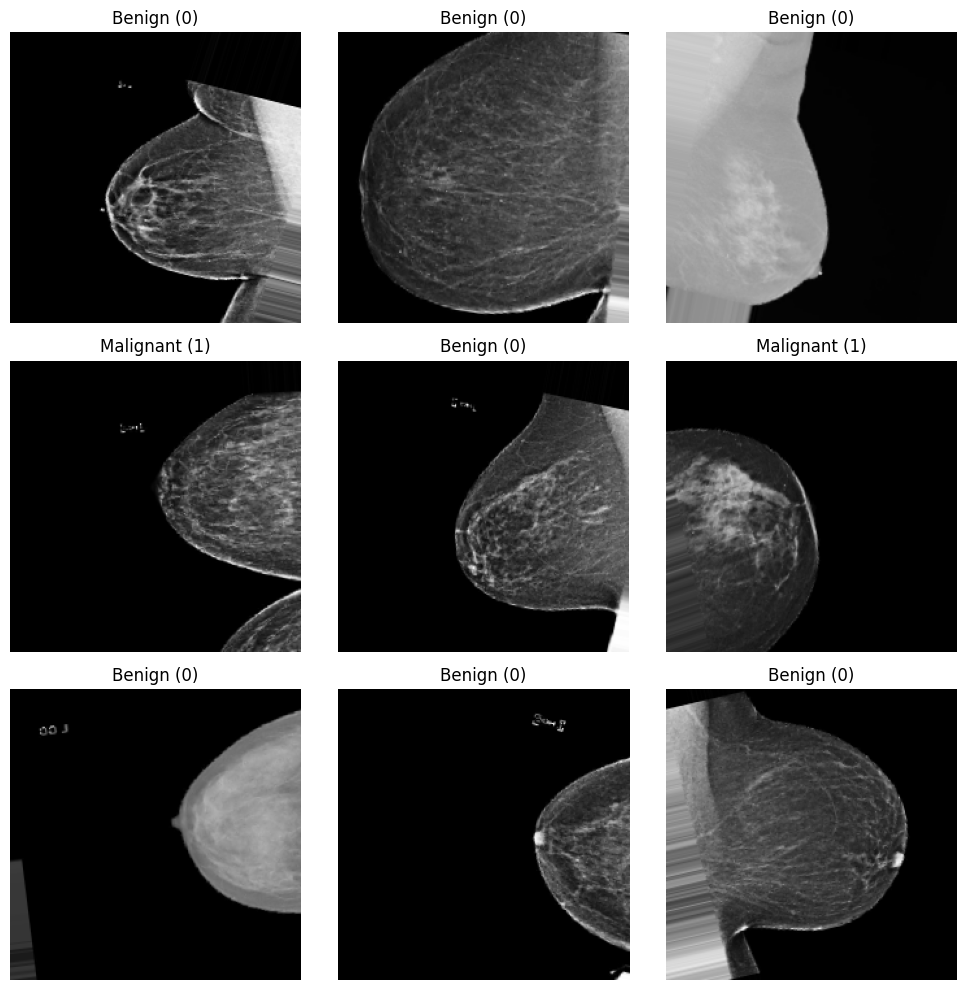

In [4]:
def visualize_samples(dataset, num_samples=9):
   
    images, labels = next(dataset)
    
    class_names = {0: 'Benign (0)', 1: 'Malignant (1)'}
    
    plt.figure(figsize=(10, 10))
    
    for i in range(min(num_samples, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        
        # Display image
        plt.imshow(images[i])

        label = int(labels[i])
        
        plt.title(class_names[label])
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()


print("\n Visualizing Training Samples...")
visualize_samples(train_ds)

In [5]:
# Training
print("\n Starting Training (Phase 1)...")

# Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss', verbose=1),
    ModelCheckpoint('best_breast_cancer_model.keras', save_best_only=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

# Train Head
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


 Starting Training (Phase 1)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1770509758.940526      90 service.cc:152] XLA service 0x7f9e24022af0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770509758.940559      90 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770509758.940563      90 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770509762.320901      90 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/75 ━━━━━━━━━━━━━━━━━━━━ 35:15 29s/step - accuracy: 0.4062 - auc: 0.4688 - loss: 0.8994 - recall: 0.5000

I0000 00:00:1770509774.947172      90 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.4864 - auc: 0.5269 - loss: 0.8996 - recall: 0.6123
Epoch 1: val_loss improved from inf to 0.65718, saving model to best_breast_cancer_model.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 99s 957ms/step - accuracy: 0.4870 - auc: 0.5272 - loss: 0.8987 - recall: 0.6115 - val_accuracy: 0.6074 - val_auc: 0.5846 - val_loss: 0.6572 - val_recall: 0.3833 - learning_rate: 1.0000e-04
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.5888 - auc: 0.5651 - loss: 0.7543 - recall: 0.3616
Epoch 2: val_loss improved from 0.65718 to 0.63340, saving model to best_breast_cancer_model.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 31s 413ms/step - accuracy: 0.5889 - auc: 0.5652 - loss: 0.7543 - recall: 0.3616 - val_accuracy: 0.6519 - val_auc: 0.5966 - val_loss: 0.6334 - val_recall: 0.1938 - learning_rate: 1.0000e-04
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.6235 - auc: 0.5706 - loss: 0.7306 - recall: 0.3560
Epoch 3: val_loss improved from 0.

In [6]:
# Fine tuning
print("\n Unfreezing top layers for Fine-Tuning (Phase 2)...")

# Unfreeze base model
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False
    
# Recompile with very low learning rate (1e-5)
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Recall(name='recall')]
)

# Continue training
history_fine = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10, # Additional epochs
    callbacks=callbacks
)


 Unfreezing top layers for Fine-Tuning (Phase 2)...
Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.6302 - auc: 0.6083 - loss: 0.6938 - recall: 0.3378
Epoch 1: val_loss improved from 0.62096 to 0.61659, saving model to best_breast_cancer_model.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 96s 888ms/step - accuracy: 0.6302 - auc: 0.6084 - loss: 0.6938 - recall: 0.3379 - val_accuracy: 0.6578 - val_auc: 0.6353 - val_loss: 0.6166 - val_recall: 0.2819 - learning_rate: 1.0000e-05
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.6269 - auc: 0.5911 - loss: 0.7152 - recall: 0.3543
Epoch 2: val_loss did not improve from 0.61659
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 386ms/step - accuracy: 0.6270 - auc: 0.5913 - loss: 0.7150 - recall: 0.3544 - val_accuracy: 0.6563 - val_auc: 0.6323 - val_loss: 0.6186 - val_recall: 0.2819 - learning_rate: 1.0000e-05
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.6378 - auc: 0.6189 - loss: 0.6801 - recall: 0.3419
Epoch 3: val_loss 


 Evaluating on Test Set...
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7358 - auc: 0.2973 - loss: 0.5565 - recall: 0.1378
Test Loss: 0.6656
Test Accuracy: 0.6131
Test AUC: 0.5893
Test Recall: 0.2812


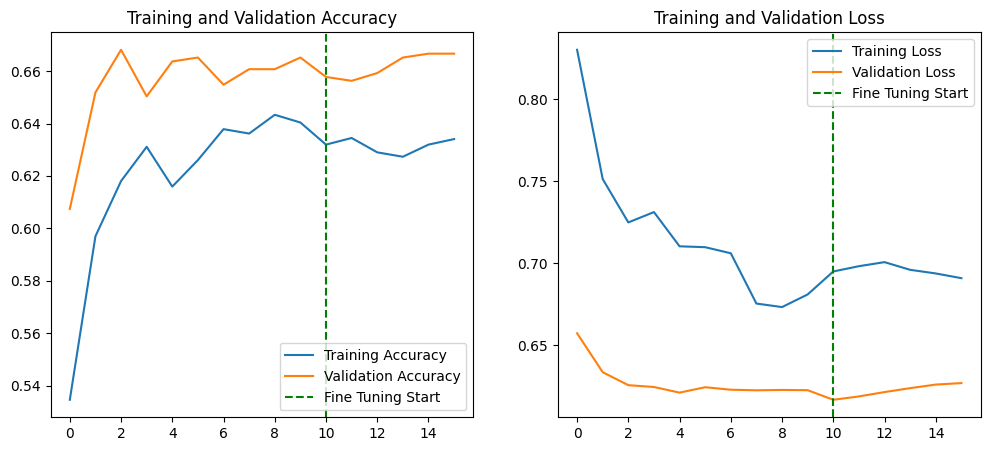

In [7]:
# Evaluation
print("\n Evaluating on Test Set...")
results = model.evaluate(test_ds)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")
print(f"Test AUC: {results[2]:.4f}")
print(f"Test Recall: {results[3]:.4f}")

# Plotting Results
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=len(history.history['accuracy']), color='green', linestyle='--', label='Fine Tuning Start')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(x=len(history.history['loss']), color='green', linestyle='--', label='Fine Tuning Start')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

Sampling random images from Test Set...
Found 336 images belonging to 2 classes.


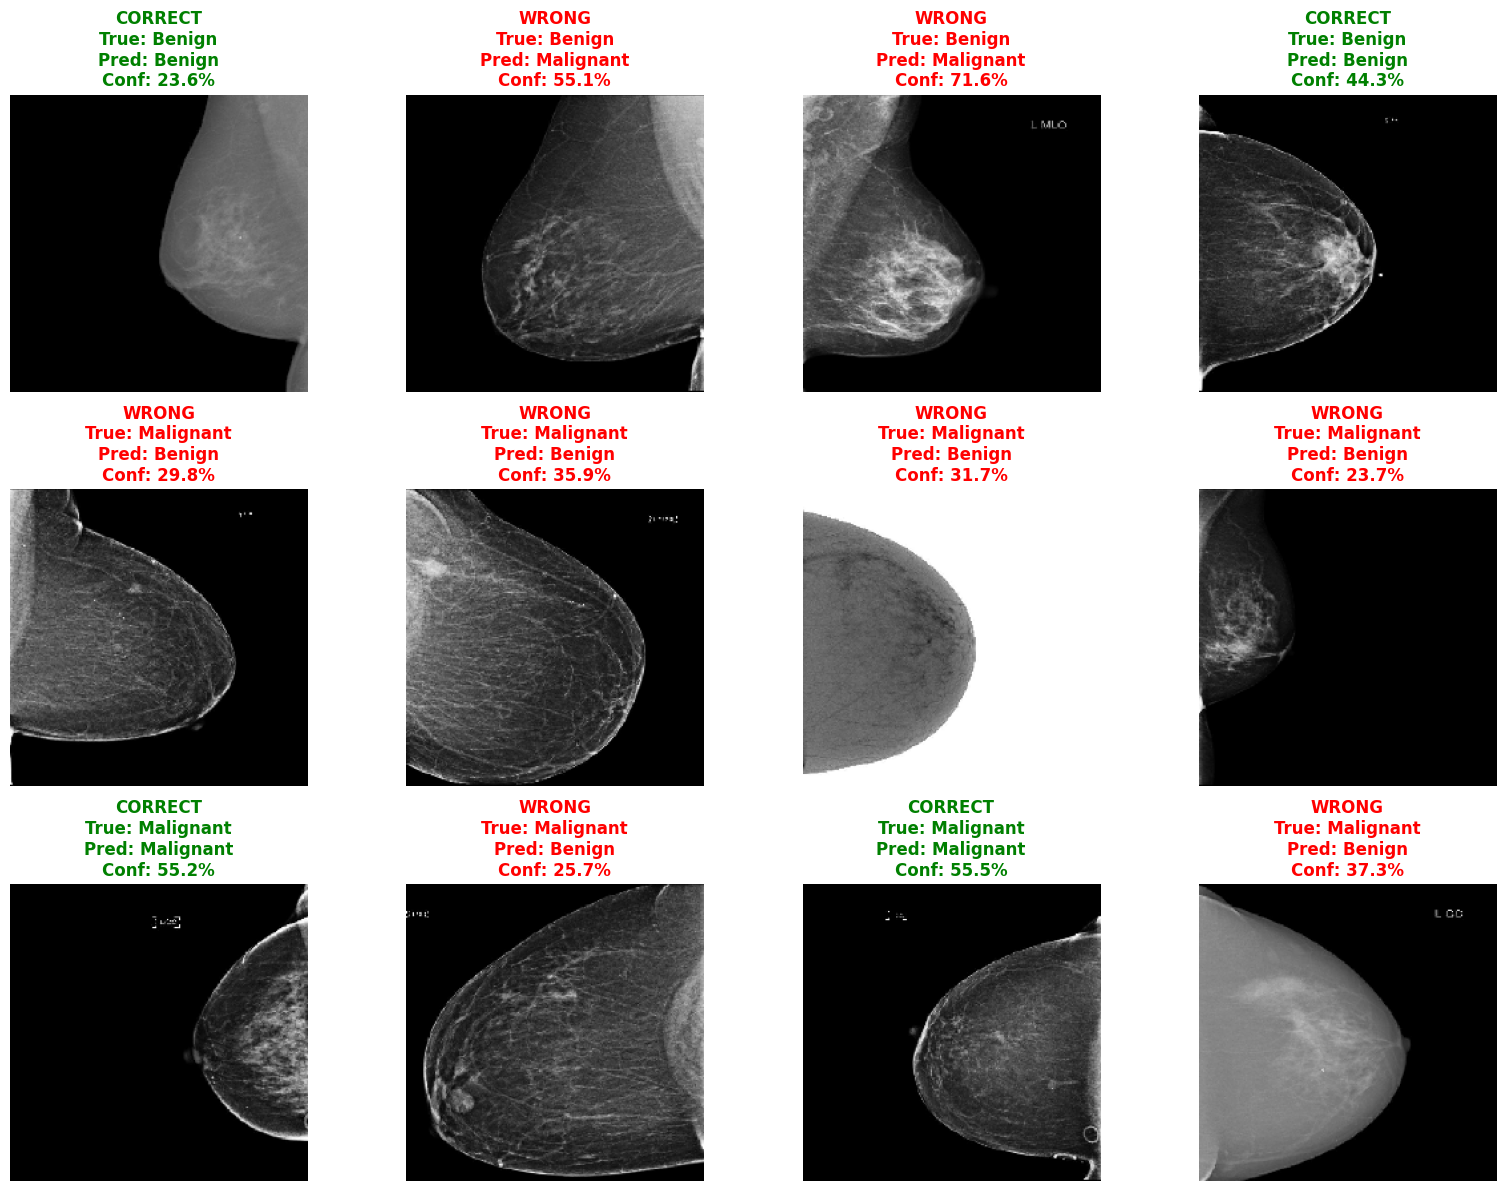

In [8]:
# Prediction

def visualize_random_predictions(model, data_dir, num_samples=12):
  
    print("Sampling random images from Test Set...")
    
    # Temporary generator just for visualization
    temp_datagen = ImageDataGenerator(rescale=1./255)
    
    random_test_ds = temp_datagen.flow_from_directory(
        os.path.join(data_dir, 'test'),
        target_size=(224, 224),
        batch_size=num_samples,
        class_mode='binary',
        shuffle=True,
        seed=None
    )
    

    images, labels = next(random_test_ds)
    predictions = model.predict(images, verbose=0)
    plt.figure(figsize=(16, 12))
    class_names = {0: 'Benign', 1: 'Malignant'}
    
    for i in range(len(images)):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i])
        
        true_label = int(labels[i])
        pred_prob = predictions[i][0]
        pred_label = 1 if pred_prob > 0.5 else 0
        
        if true_label == pred_label:
            color = 'green'
            result_text = "CORRECT"
        else:
            color = 'red'
            result_text = "WRONG"
            

        title = (f"{result_text}\n"
                 f"True: {class_names[true_label]}\n"
                 f"Pred: {class_names[pred_label]}\n"
                 f"Conf: {pred_prob:.1%}")
        
        plt.title(title, color=color, fontweight='bold')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

visualize_random_predictions(model, DATA_DIR, num_samples=12)